In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.model_selection import train_test_split, KFold,cross_validate, StratifiedKFold,GridSearchCV,  RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from scipy.stats import randint
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

df = pd.read_csv('train.csv')
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 0:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 1:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 2:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 3:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 4:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [3]:
df = df.rename(columns={
    'datetime': '날짜',
    'season': '계절',
    'holiday': '주말',
    'workingday': '주중',
    'weather' : '날씨',
    'temp': '온도',
    'atemp': '체감온도',
    'humidity': '습도',
    'windspeed': '풍속',
    'casual': '사전등록X',
    'registered': '사전등록O',
    'count': '대여횟수'
})

df

,날짜,계절,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,사전등록O,대여횟수
0,2011-01-01 0:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 1:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 2:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 3:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 4:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [4]:
계절별대여횟수 = df.groupby('계절')['대여횟수'].sum()
계절별대여횟수

계절
1    312498
2    588282
3    640662
4    544034
Name: 대여횟수, dtype: int64

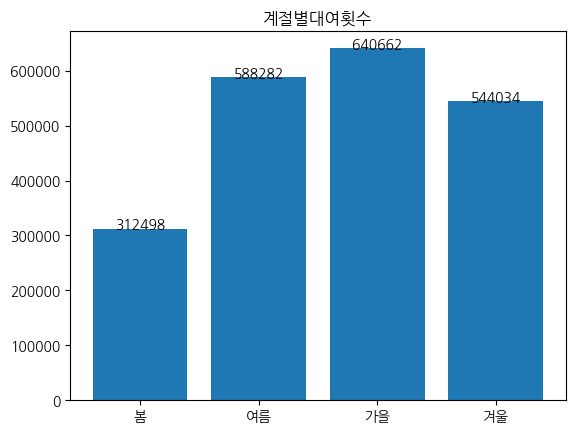

In [5]:
plt.bar(range(len(계절별대여횟수)), 계절별대여횟수)
plt.title('계절별대여횟수')
plt.xticks(
    range(len(계절별대여횟수)),
    ["봄", "여름", "가을", "겨울"]
)

for i, v in enumerate(계절별대여횟수):
    plt.text(i, v, f"{v}", ha='center')

plt.show()

In [6]:
날씨별대여횟수 = df.groupby('날씨')['대여횟수'].sum()
날씨별대여횟수

날씨
1    1476063
2     507160
3     102089
4        164
Name: 대여횟수, dtype: int64

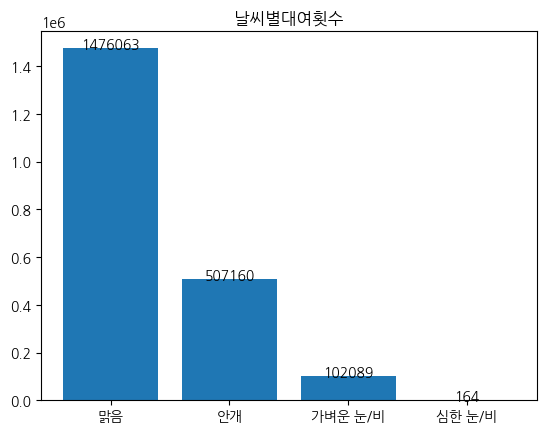

In [7]:
plt.bar(range(len(날씨별대여횟수)), 날씨별대여횟수)
plt.title('날씨별대여횟수')
plt.xticks(
    range(len(날씨별대여횟수)),
    ["맑음", "안개", "가벼운 눈/비", "심한 눈/비"]
)

for i, v in enumerate(날씨별대여횟수):
    plt.text(i, v, f"{v}", ha='center')

plt.show()

In [8]:
df['온도구간'] = (df['온도'] // 10).astype(int) * 10
df

,날짜,계절,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,사전등록O,대여횟수,온도구간
0,2011-01-01 0:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,0
1,2011-01-01 1:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,0
2,2011-01-01 2:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,0
3,2011-01-01 3:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,0
4,2011-01-01 4:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,10
10882,2012-12-19 20:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,10
10883,2012-12-19 21:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,10
10884,2012-12-19 22:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,10


,날짜,계절,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,사전등록O,대여횟수,온도구간,시간,년도,월,일
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,0,0,2011,1,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,0,1,2011,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,0,2,2011,1,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,0,3,2011,1,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,0,4,2011,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,10,19,2012,12,19
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,10,20,2012,12,19
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,10,21,2012,12,19
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,10,22,2012,12,19


In [10]:
시간별대여횟수 = df.groupby('시간')['대여횟수'].sum()
시간별대여횟수

시간
0      25088
1      15372
2      10259
3       5091
4       2832
5       8935
6      34698
7      96968
8     165060
9     100910
10     79667
11     95857
12    116968
13    117551
14    111010
15    115960
16    144266
17    213757
18    196472
19    143767
20    104204
21     79057
22     60911
23     40816
Name: 대여횟수, dtype: int64

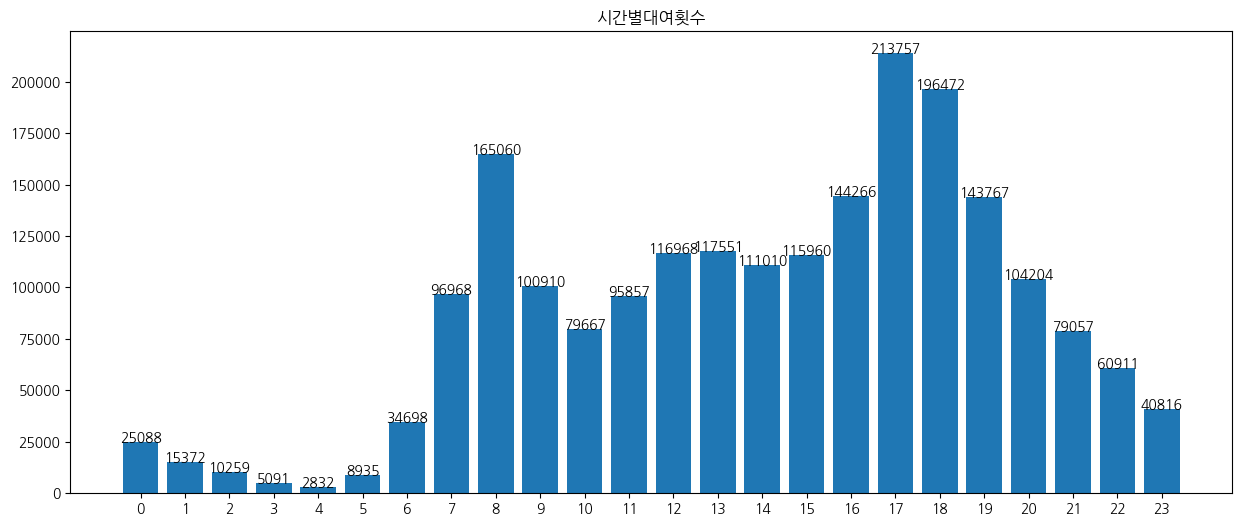

In [11]:
plt.figure(figsize=(15,6))
plt.bar(시간별대여횟수.index, 시간별대여횟수)
plt.xticks(시간별대여횟수.index)
plt.title('시간별대여횟수')
for i, v in enumerate(시간별대여횟수):
    plt.text(i, v + 5, f"{v}", ha='center')

plt.show()

In [12]:
df['회원이용률'] = df['사전등록O'] / (df['대여횟수'] + 1)
df

,날짜,계절,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,사전등록O,대여횟수,온도구간,시간,년도,월,일,회원이용률
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,0,0,2011,1,1,0.764706
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,0,1,2011,1,1,0.780488
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,0,2,2011,1,1,0.818182
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,0,3,2011,1,1,0.714286
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,0,4,2011,1,1,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,10,19,2012,12,19,0.976261
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,10,20,2012,12,19,0.954545
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,10,21,2012,12,19,0.970414
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,10,22,2012,12,19,0.900000


In [112]:
df['날짜'] = pd.to_datetime(df['날짜'])
df['시간'] = df['날짜'].dt.hour
df['년도'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month
df['일'] = df['날짜'].dt.day
df['러시아워'] = df['시간'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)
df['온도습도'] = df['온도'] * df['습도']
df['최악의날씨'] = df['날씨'].apply(lambda x: 1 if x >= 3 else 0)
df['좋은날씨'] = df['날씨'].apply(lambda x: 1 if x == 1 else 0)
def time_group(hour):
    if 7 <= hour <= 9:
        return "출근"
    elif 17 <= hour <= 19:
        return "퇴근"
    elif 12 <= hour <= 13:
        return "점심"
    elif 0 <= hour <= 5:
        return "심야"
    else:
        return "일반"
df['날씨점수'] = df['좋은날씨'] - df['최악의날씨']
df['시간_세분화'] = df['시간'].apply(time_group)
df['출퇴근_시간'] = df['시간'] * df['주중']

In [113]:

df

,날짜,계절,주말,주중,날씨,온도,체감온도,습도,풍속,사전등록X,...,회원이용률,러시아워,온도습도,최악의날씨,좋은날씨,시간_세분화,온도2,습도2,날씨점수,출퇴근_시간
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,...,0.764706,0,797.04,0,1,심야,96.8256,6561,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,...,0.780488,0,721.60,0,1,심야,81.3604,6400,1,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,...,0.818182,0,721.60,0,1,심야,81.3604,6400,1,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,...,0.714286,0,738.00,0,1,심야,96.8256,5625,1,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,...,0.500000,0,738.00,0,1,심야,96.8256,5625,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,...,0.976261,1,779.00,0,1,퇴근,242.7364,2500,1,19
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,...,0.954545,0,841.32,0,1,일반,217.8576,3249,1,20
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,...,0.970414,0,850.34,0,1,일반,194.3236,3721,1,21
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,...,0.900000,0,850.34,0,1,일반,194.3236,3721,1,22


In [114]:
X = df[['시간','출퇴근_시간','체감온도','년도','월','일', '주말','주중','계절', '날씨','온도','습도','러시아워','온도습도','날씨점수','시간_세분화']]
X = pd.get_dummies(X, columns=['시간_세분화'], drop_first=True)
y = df['대여횟수']

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [121]:
# 1. 파라미터 설정
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 2. 교차검증
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. 그리드서치
grid_search = GridSearchCV(
    estimator=XGBmodel,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 4. 결과 확인
print("최적 파라미터:", grid_search.best_params_)
print("최고 CV RMSE:", -grid_search.best_score_)

# 5. 최적 모델 꺼내기
bestXGBmodel = grid_search.best_estimator_

bestXGBmodel.fit(X_train, y_train)

# 예측
y_pred = bestXGBmodel.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)
RFmodel = RandomForestRegressor(max_depth=15, random_state=42,  n_estimators=300, n_jobs=-1 )

HGMmodel = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=5,
    max_iter=300,
    random_state=42
)


LGBMmodel = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    random_state=42
)

LSmodel = Lasso(alpha=0.1)

Rmodel = Ridge(alpha=10)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적 파라미터: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0.8}
최고 CV RMSE: 40.15372009277344
RMSE: 37.41332431016389


===== 모델별 교차검증 RMSE 결과 =====
RandomForest
  각 폴드 RMSE : [42.1152 41.533  46.8597 47.4424 44.2512]
  평균 RMSE    : 44.4403
  표준편차     : 2.3983

HistGB
  각 폴드 RMSE : [42.272  40.8496 46.147  44.5387 44.2174]
  평균 RMSE    : 43.6049
  표준편차     : 1.8481

XGBoost
  각 폴드 RMSE : [38.6819 38.3298 41.8682 40.7773 41.1114]
  평균 RMSE    : 40.1537
  표준편차     : 1.3956

LightGBM
  각 폴드 RMSE : [42.6375 41.4009 46.0244 44.6706 44.2524]
  평균 RMSE    : 43.7972
  표준편차     : 1.6135

Lasso
  각 폴드 RMSE : [112.8388 109.8711 112.7615 111.8739 110.0937]
  평균 RMSE    : 111.4878
  표준편차     : 1.2770

Ridge
  각 폴드 RMSE : [112.8423 109.8995 112.8344 111.9671 110.0438]
  평균 RMSE    : 111.5174
  표준편차     : 1.3024

===== 평균 RMSE 순위 =====
1. XGBoost : 40.1537
2. HistGB : 43.6049
3. LightGBM : 43.7972
4. RandomForest : 44.4403
5. Lasso : 111.4878
6. Ridge : 111.5174


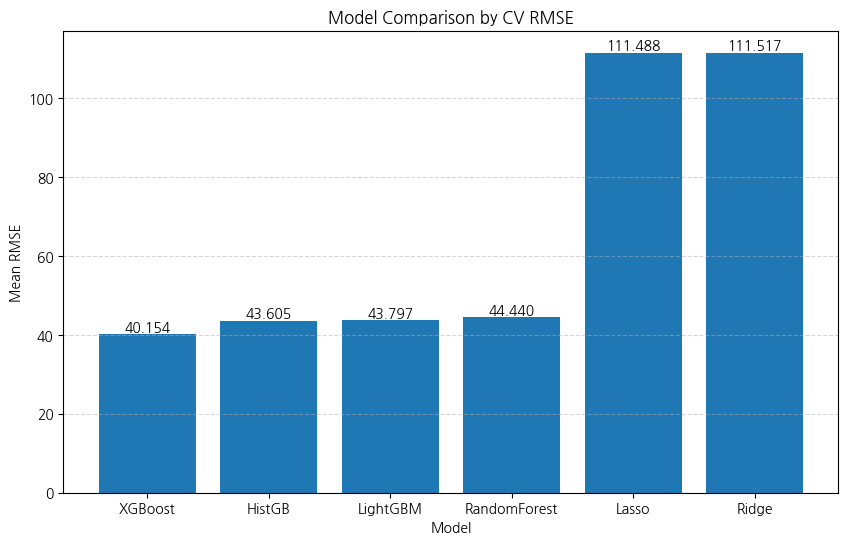

In [122]:
# 1. 모델 비교
models = {
    "RandomForest": RFmodel,
    "HistGB": HGMmodel,
    "XGBoost": bestXGBmodel,
    "LightGBM": LGBMmodel,
    "Lasso": LSmodel,
    "Ridge": Rmodel
}


# =========================
# 2. 교차검증 설정
# =========================
splitter = KFold(n_splits=5, shuffle=True, random_state=42)


# =========================
# 3. 각 모델별 교차검증 + RMSE 저장
# =========================
results = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=splitter,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    rmse_scores = -scores['test_score']   # 음수를 양수 RMSE로 바꾸기
    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)
    
    results[name] = {
        "fold_rmse": rmse_scores,
        "mean_rmse": mean_rmse,
        "std_rmse": std_rmse
    }


# =========================
# 4. 결과 출력
# =========================
print("===== 모델별 교차검증 RMSE 결과 =====")

for name, info in results.items():
    print(f"{name}")
    print(f"  각 폴드 RMSE : {np.round(info['fold_rmse'], 4)}")
    print(f"  평균 RMSE    : {info['mean_rmse']:.4f}")
    print(f"  표준편차     : {info['std_rmse']:.4f}")
    print()


# =========================
# 5. 평균 RMSE 기준 정렬
# =========================
sorted_results = sorted(results.items(), key=lambda x: x[1]["mean_rmse"])

model_names = [item[0] for item in sorted_results]
mean_rmse_values = [item[1]["mean_rmse"] for item in sorted_results]


print("===== 평균 RMSE 순위 =====")
for i, (name, info) in enumerate(sorted_results, start=1):
    print(f"{i}. {name} : {info['mean_rmse']:.4f}")


# =========================
# 6. 그래프 그리기
# =========================
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, mean_rmse_values)

plt.title("Model Comparison by CV RMSE")
plt.xlabel("Model")
plt.ylabel("Mean RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(mean_rmse_values):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

plt.show()